## 0. Libraries

In [1]:
# Import LoopDetect core and numpy
import numpy as np
import loopdetect.core as ld
import loopdetect.examples as lde
import numdifftools
import pandas as pd

from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

d:\Work\StudentJob\Jana Wolf\LoopDetect_2025\env\lib\loopdetect_python_3.12\Lib\site-packages\loopdetect\examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Configuration

In [2]:
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "text.usetex": True,  # requires LaTeX installation
    "axes.linewidth": 1.2,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

colors = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB']
colors_02 = ['#332288', '#117733', '#DDCC77', '#882255', '#AA4499', '#88CCEE', '#44AA99', '#999933', '#CC6677', '#DDDDDD']

## 2. Main reproduction

The model for the mitogen-activated phosphorylation kinase (MAPK) cascade proposed in [7] captures the first, second and third level of a phosphorylation cascade which occurs for example in epidermal growth factor (EGF) signaling. The kinase on the first level can be reversibly phosphorylated once, the kinases on levels two andthree can be reversibly phosphorylated twice. The phosphorylated kinase of the first level acts positively on the phosphorylations on the second level, the double phosphorylated kinase of the second level acts positively on the phosphorylations on the third level. The model contains an explicit negative feedback regulation: The double phosphorylated kinase of the third level acts negatively on the phosphorylation on the first level. All phosphorylations are governed by Michaelis-Menten kinetics. The model contains eight variables, ten rate coefficients, eleven inhibition or activation constants, and one Hill coefficient.

$$
\begin{aligned}
\frac{dS_1}{dt} &=
- k_1 \, \frac{S_1}{kn_2 + S_1} \, \frac{kn_1^{n_1}}{kn_1^{n_1} + S_8^{n_1}}
+ k_2 \, \frac{S_2}{S_2 + kn_3}, \\[8pt]

\frac{dS_2}{dt} &=
\phantom{-}\, k_1 \, \frac{S_1}{kn_2 + S_1} \, \frac{kn_1^{n_1}}{kn_1^{n_1} + S_8^{n_1}}
- k_2 \, \frac{S_2}{S_2 + kn_3}, \\[10pt]

\frac{dS_3}{dt} &=
\phantom{-}\, k_6 \, \frac{S_4}{kn_7 + S_4}
- k_3 \, \frac{S_2 \, S_3}{kn_4 + S_3}, \\[10pt]

\frac{dS_4}{dt} &=
\phantom{-}\, k_3 \, \frac{S_2 \, S_3}{kn_4 + S_3}
- k_6 \, \frac{S_4}{kn_7 + S_4}
+ k_5 \, \frac{S_5}{kn_6 + S_5}
- k_4 \, \frac{S_2 \, S_4}{kn_5 + S_4}, \\[10pt]

\frac{dS_5}{dt} &=
\phantom{-}\, k_4 \, \frac{S_2 \, S_4}{kn_5 + S_4}
- k_5 \, \frac{S_5}{kn_6 + S_5}, \\[10pt]

\frac{dS_6}{dt} &=
\phantom{-}\, k_{10} \, \frac{S_7}{kn_{11} + S_7}
- k_7 \, \frac{S_5 \, S_6}{kn_8 + S_6}, \\[10pt]

\frac{dS_7}{dt} &=
\phantom{-}\, k_7 \, \frac{S_5 \, S_6}{kn_8 + S_6}
- k_{10} \, \frac{S_7}{kn_{11} + S_7}
- k_8 \, \frac{S_5 \, S_7}{kn_9 + S_7}
+ k_9 \, \frac{S_8}{kn_{10} + S_8}, \\[10pt]

\frac{dS_8}{dt} &=
\phantom{-}\, k_8 \, \frac{S_5 \, S_7}{kn_9 + S_7}
- k_9 \, \frac{S_8}{kn_{10} + S_8}.
\end{aligned}
$$


In the table below, the notation we used is given together with the notation used in the original publication [7], and we provide the initial conditions and reference parameter set published together with the model.

**Initial conditions**

| Var | Name (short) | Name (long) | Initial value |
|------:|-------------|-------------|---------------|
| S₁ | MKKK | MAPKKK | 100 nM |
| S₂ | MKKK-P | MAPKKK* | 0 |
| S₃ | MKK | MAPKK | 300 nM |
| S₄ | MKK-P | MAPKK* | 0 |
| S₅ | MKK-PP | MAPKK** | 0 |
| S₆ | MAPK | MAPK | 300 nM |
| S₇ | MAPK-P | MAPK* | 0 |
| S₈ | MAPK-PP | MAPK** | 0 |


**Parameters**
| Parameter | Symbol | Value | Units |
|----------:|--------|-------|-------|
| k₁ | V₁ | 2.5 | nM·s⁻¹ |
| k₂ | V₂ | 0.25 | nM·s⁻¹ |
| k₃ | k₃ | 0.025 | s⁻¹ |
| k₄ | k₄ | 0.025 | s⁻¹ |
| k₅ | V₅ | 0.75 | nM·s⁻¹ |
| k₆ | V₆ | 0.75 | nM·s⁻¹ |
| k₇ | k₇ | 0.025 | s⁻¹ |
| k₈ | k₈ | 0.025 | s⁻¹ |
| k₉ | V₉ | 0.5 | nM·s⁻¹ |
| k₁₀ | V₁₀ | 0.5 | nM·s⁻¹ |


The MAPK cascade model without explicit feedback regulation is exactly the same as the one described above, but for the corresponding regulation term omitted from the ODE system. Therefore, only the first two equations of the ODE model are altered to:

$$
\begin{aligned}
\frac{dS_1}{dt} &=
- k_1 \, \frac{S_1}{kn_2 + S_1}
+ k_2 \, \frac{S_2}{S_2 + kn_3}, \\[8pt]

\frac{dS_2}{dt} &=
\phantom{-}\, k_1 \, \frac{S_1}{kn_2 + S_1}
- k_2 \, \frac{S_2}{S_2 + kn_3}.
\end{aligned}
$$


## **2.1. Reduced MAPK with explicit feedback regulation** 
(I want to understand where and what is the explicit feedback regulation doing to the dynamics of the system)

In [3]:
def model_mapk_simple_w_feedback(y, klin, kn, n1):
    S1, S2, S3, S4, S5, S6, S7, S8 = y
    
    # Unpack kinetic parameters
    k1, k2, k3, k4, k5, k6, k7, k8, k9, k10 = klin
    
    # Unpack saturation constants
    kn1, kn2, kn3, kn4, kn5, kn6, kn7, kn8, kn9, kn10, kn11 = kn
    
    # dS1/dt
    term_inhibit = (kn1**n1) / (kn1**n1 + S8**n1)
    dS1 = -k1 * (S1/(kn2 + S1)) * term_inhibit \
          + k2 * (S2/(S2 + kn3))
    
    # dS2/dt
    dS2 =  k1 * (S1/(kn2 + S1)) * term_inhibit \
          - k2 * (S2/(S2 + kn3))
    
    # dS3/dt
    dS3 = k6 * (S4/(kn7 + S4)) \
          - k3 * (S2*S3/(kn4 + S3))
    
    # dS4/dt
    dS4 = k3 * (S2*S3/(kn4 + S3)) \
          - k6 * (S4/(kn7 + S4)) \
          + k5 * (S5/(kn6 + S5)) \
          - k4 * (S2*S4/(kn5 + S4))
    
    # dS5/dt
    dS5 = k4 * (S2*S4/(kn5 + S4)) \
          - k5 * (S5/(kn6 + S5))
    
    # dS6/dt
    dS6 = k10 * (S7/(kn11 + S7)) \
          - k7 * (S5*S6/(kn8 + S6))
    
    # dS7/dt
    dS7 =  k7 * (S5*S6/(kn8 + S6)) \
            - k10 * (S7/(kn11 + S7)) \
            - k8 * (S5*S7/(kn9 + S7)) \
            + k9 * (S8/(kn10 + S8))
    
    # dS8/dt
    dS8 =  k8 * (S5*S7/(kn9 + S7)) \
           - k9 * (S8/(kn10 + S8))
    
    return np.array([dS1, dS2, dS3, dS4, dS5, dS6, dS7, dS8], dtype=float)

def solve_model_mapk_simple_w_feedback(initial_conditions, time_points, klin, kn, n1):
    def ode(t, x):
        return model_mapk_simple_w_feedback(x, klin, kn, n1)
    
    sol = solve_ivp(
        ode,
        [time_points[0], time_points[-1]],
        initial_conditions,
        t_eval=time_points,
        method="RK45",
        rtol=1e-6,
        atol=1e-9
    )
    return sol


In [16]:
# klin = [k1, k2, k3, k4, k5, k6, k7, k8, k9, k10]
# kn   = [kn1, kn2, kn3, kn4, kn5, kn6, kn7, kn8, kn9, kn10, kn11]
# n    = n1     # only the first reaction uses a Hill exponent
# s_star_mapk = [(1,1,1,1,1,1,1,1)]

klin = [
    2.5,        # k1
    0.25,       # k2
    0.025,      # k3
    0.025,      # k4
    0.75,       # k5
    0.75,       # k6
    0.025,      # k7
    0.025,      # k8
    0.5,        # k9
    0.5         # k10
]

kn = [
    9,          # kn1 = KI
    10,         # kn2 = K1
    8,          # kn3 = K2
    15,         # kn4
    15,         # kn5
    15,         # kn6
    15,         # kn7
    15,         # kn8
    15,         # kn9
    15,         # kn10
    15          # kn11
]

n1 = 1
initial_conditions = [
    100,    # S1: MKKK, MAPKKK
    0,      # S2: MKKK-P, MKKK*
    300,    # S3: MKK, MAPKK
    0,      # S4: MKK-P, MAPKK*,
    0,      # S5: MKK-PP, MAPKK**
    300,    # S6: MAPK, MAPK
    0,      # S7: MAPK-P, MAPK*
    0       # S8: MAPK-PP, MAPK**
]

labels = ['MAPKKK', 'MAPKKK*', 'MAPKK', 'MAPKK*', 'MAPKK**', 'MAPK', 'MAPK*', 'MAPK**']

In [5]:
# Jacobian calculation

j_matrix = numdifftools.Jacobian(lambda x: model_mapk_simple_w_feedback(x, klin, kn, n1),method="central")(initial_conditions)
signed_jacobian = np.sign(j_matrix)

In [6]:
print("Jacobian matrix:")
print(j_matrix)
print("Signed Jacobian matrix:")
print(signed_jacobian)

Jacobian matrix:
[[-0.00206612  0.03125     0.          0.          0.          0.
   0.          0.25252525]
 [ 0.00206612 -0.03125     0.          0.          0.          0.
   0.         -0.25252525]
 [ 0.         -0.02380952  0.          0.05        0.          0.
   0.          0.        ]
 [ 0.          0.02380952  0.         -0.05        0.05        0.
   0.          0.        ]
 [ 0.          0.          0.          0.         -0.05        0.
   0.          0.        ]
 [ 0.          0.          0.          0.         -0.02380952  0.
   0.03333333  0.        ]
 [ 0.          0.          0.          0.          0.02380952  0.
  -0.03333333  0.03333333]
 [ 0.          0.          0.          0.          0.          0.
   0.         -0.03333333]]
Signed Jacobian matrix:
[[-1.  1.  0.  0.  0.  0.  0.  1.]
 [ 1. -1.  0.  0.  0.  0.  0. -1.]
 [ 0. -1.  0.  1.  0.  0.  0.  0.]
 [ 0.  1.  0. -1.  1.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  1.  0.]
 [ 0

In [7]:
# Find loops
res_tab_complex = ld.find_loops_vset(model_mapk_simple_w_feedback,
                                     vset=[initial_conditions],
                                     klin=klin,
                                     kn=kn,
                                     n1=n1,
                                     max_num_loops=10,
                                     compute_full_list=True)
print(res_tab_complex['loop_rep'][0])

        loop  length  sign
0  (0, 1, 0)       2     1
1     (0, 0)       1    -1
2     (1, 1)       1    -1
3     (3, 3)       1    -1
4     (4, 4)       1    -1
5     (6, 6)       1    -1
6     (7, 7)       1    -1


In [10]:
# Find loops
res_tab_complex = ld.find_loops_vset(model_mapk_simple_w_feedback,
                                     vset=[sol.y[:, -1]],
                                     klin=klin,
                                     kn=kn,
                                     n1=n1,
                                     max_num_loops=10,
                                     compute_full_list=True)
print(res_tab_complex['loop_rep'][0])

                          loop  length  sign
0                    (0, 1, 0)       2     1
1  (0, 1, 2, 3, 4, 5, 6, 7, 0)       8     1
2     (0, 1, 2, 3, 4, 6, 7, 0)       7     1
3        (0, 1, 2, 3, 4, 7, 0)       6    -1
4     (0, 1, 3, 4, 5, 6, 7, 0)       7    -1
5        (0, 1, 3, 4, 6, 7, 0)       6    -1
6           (0, 1, 3, 4, 7, 0)       5     1
7        (0, 1, 4, 5, 6, 7, 0)       6    -1
8           (0, 1, 4, 6, 7, 0)       5    -1
9              (0, 1, 4, 7, 0)       4     1


In [11]:
loop_list = ld.find_loops(j_matrix)
ld.loop_summary(loop_list)

length,1,2
total,6,1
neg,6,0
pos,0,1


In [9]:
sol = solve_model_mapk_simple_w_feedback(initial_conditions,
                              time_points=np.linspace(0, 3650, 3651),
                                klin=klin,
                                kn=kn,
                                n1=n1)

In [12]:
sol = solve_model_mapk_simple_w_feedback(sol.y[:,-1],
                              time_points=np.linspace(0, 5000, 5001),
                                klin=klin,
                                kn=kn,
                                n1=n1)

In [13]:
investigate_label = ['MAPKK** (S5)', 'MAPK (S6)', 'MAPK* (S7)']
investigate_index = [4, 5, 6]

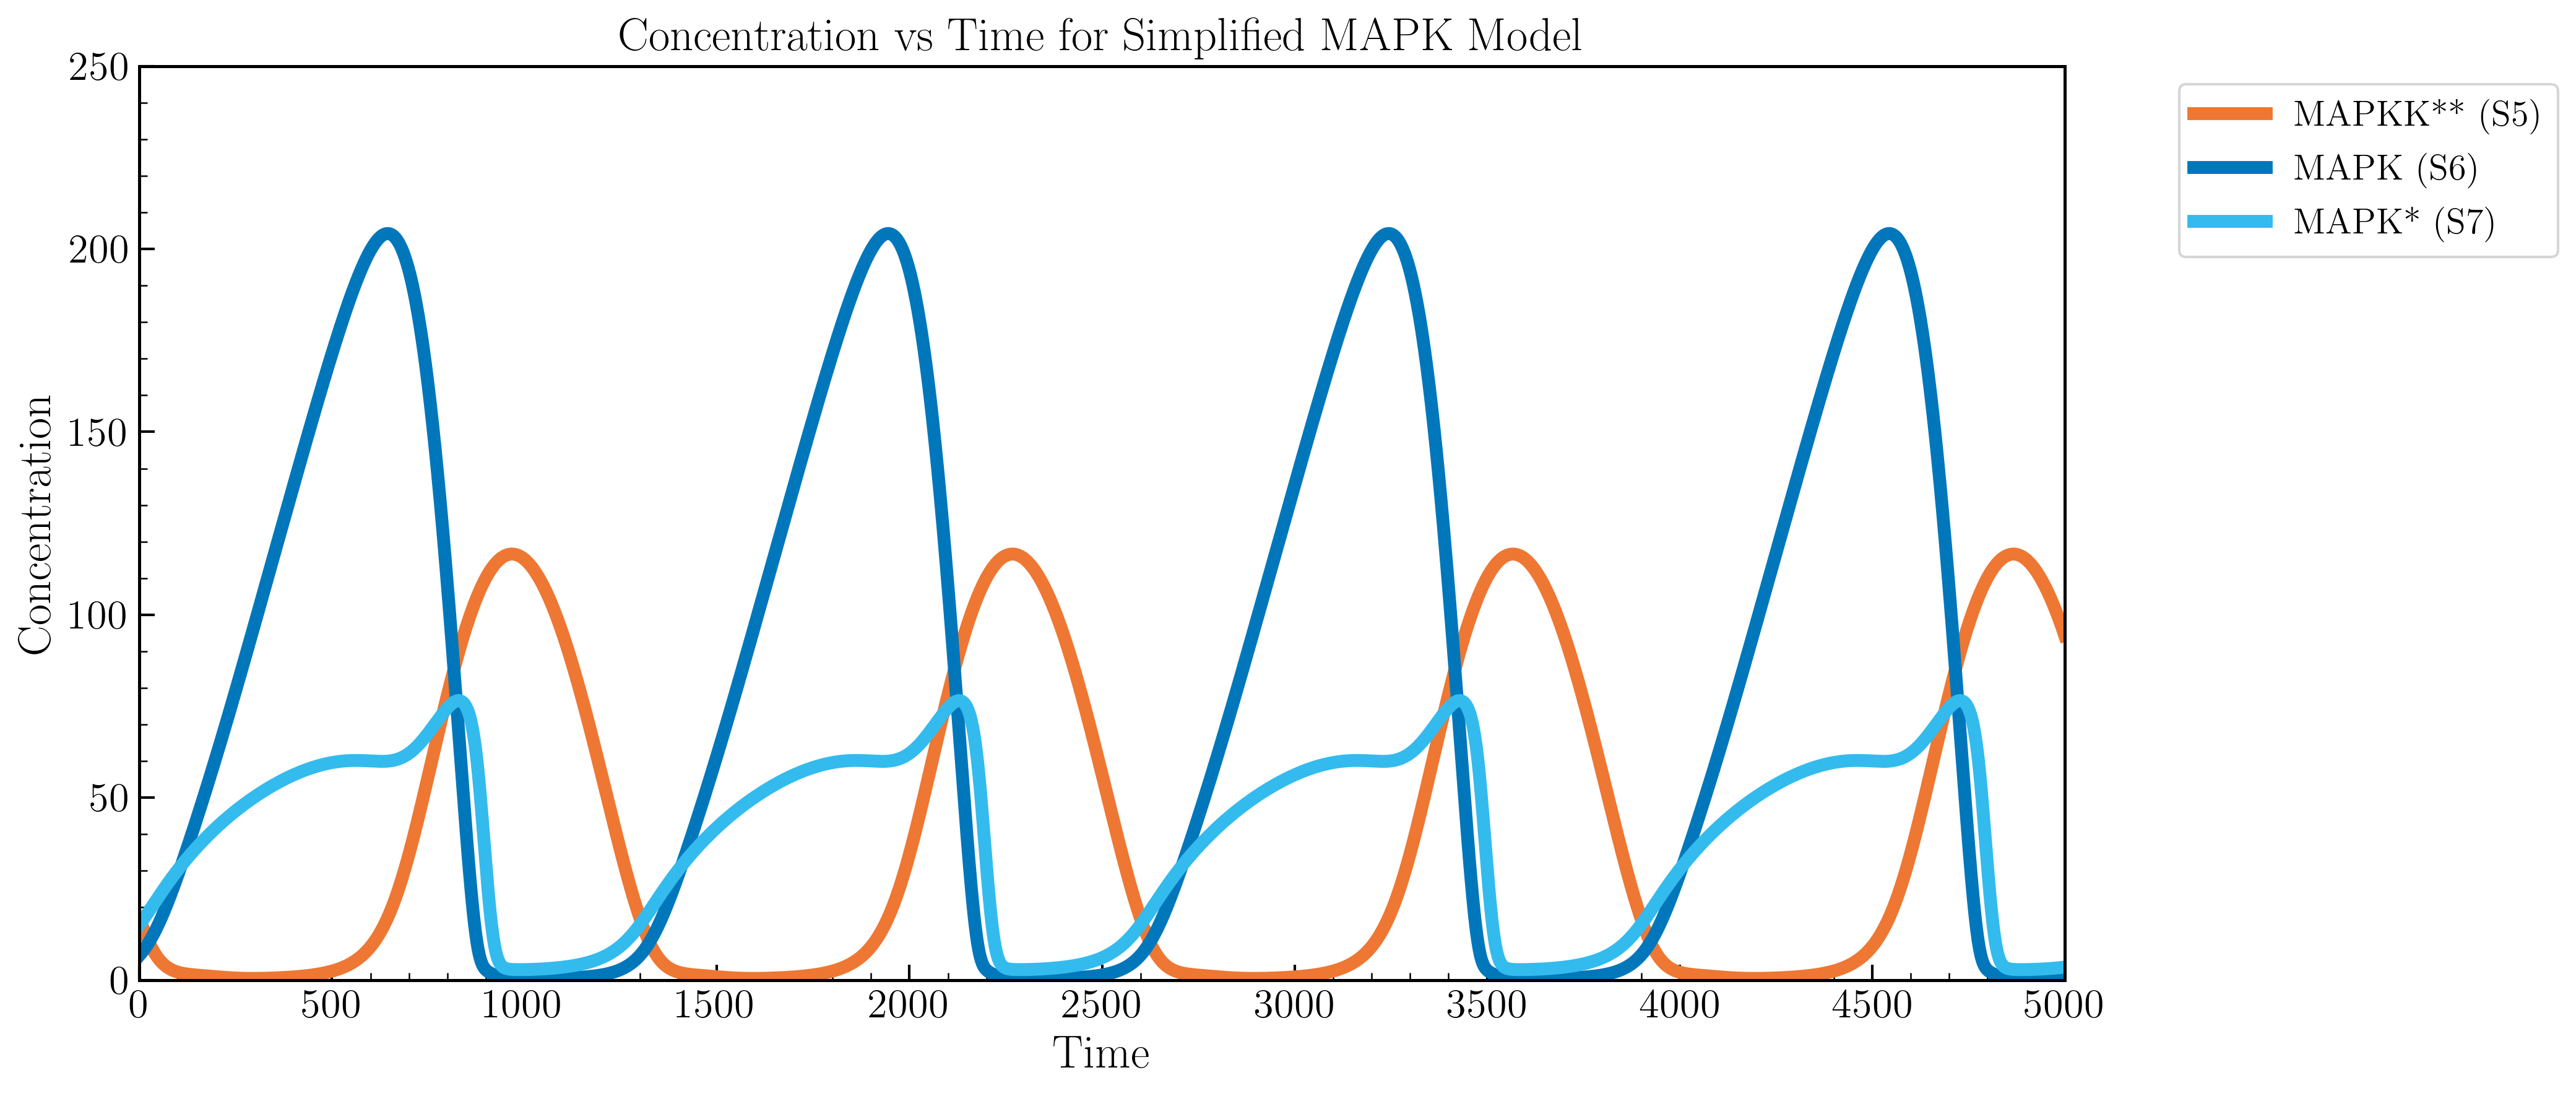

In [14]:
# Plot
plt.figure(figsize=(14, 6))
for i, c in enumerate(colors[:3]):
    plt.plot(sol.t, sol.y[investigate_index[i]], lw=5, color=c, label=investigate_label[i])
plt.xlim(0, 5000)
plt.xticks(np.arange(0, 5001, 500))
plt.ylim(0, 250)
plt.yticks(np.arange(0, 251, 50))
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Concentration vs Time for Simplified MAPK Model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

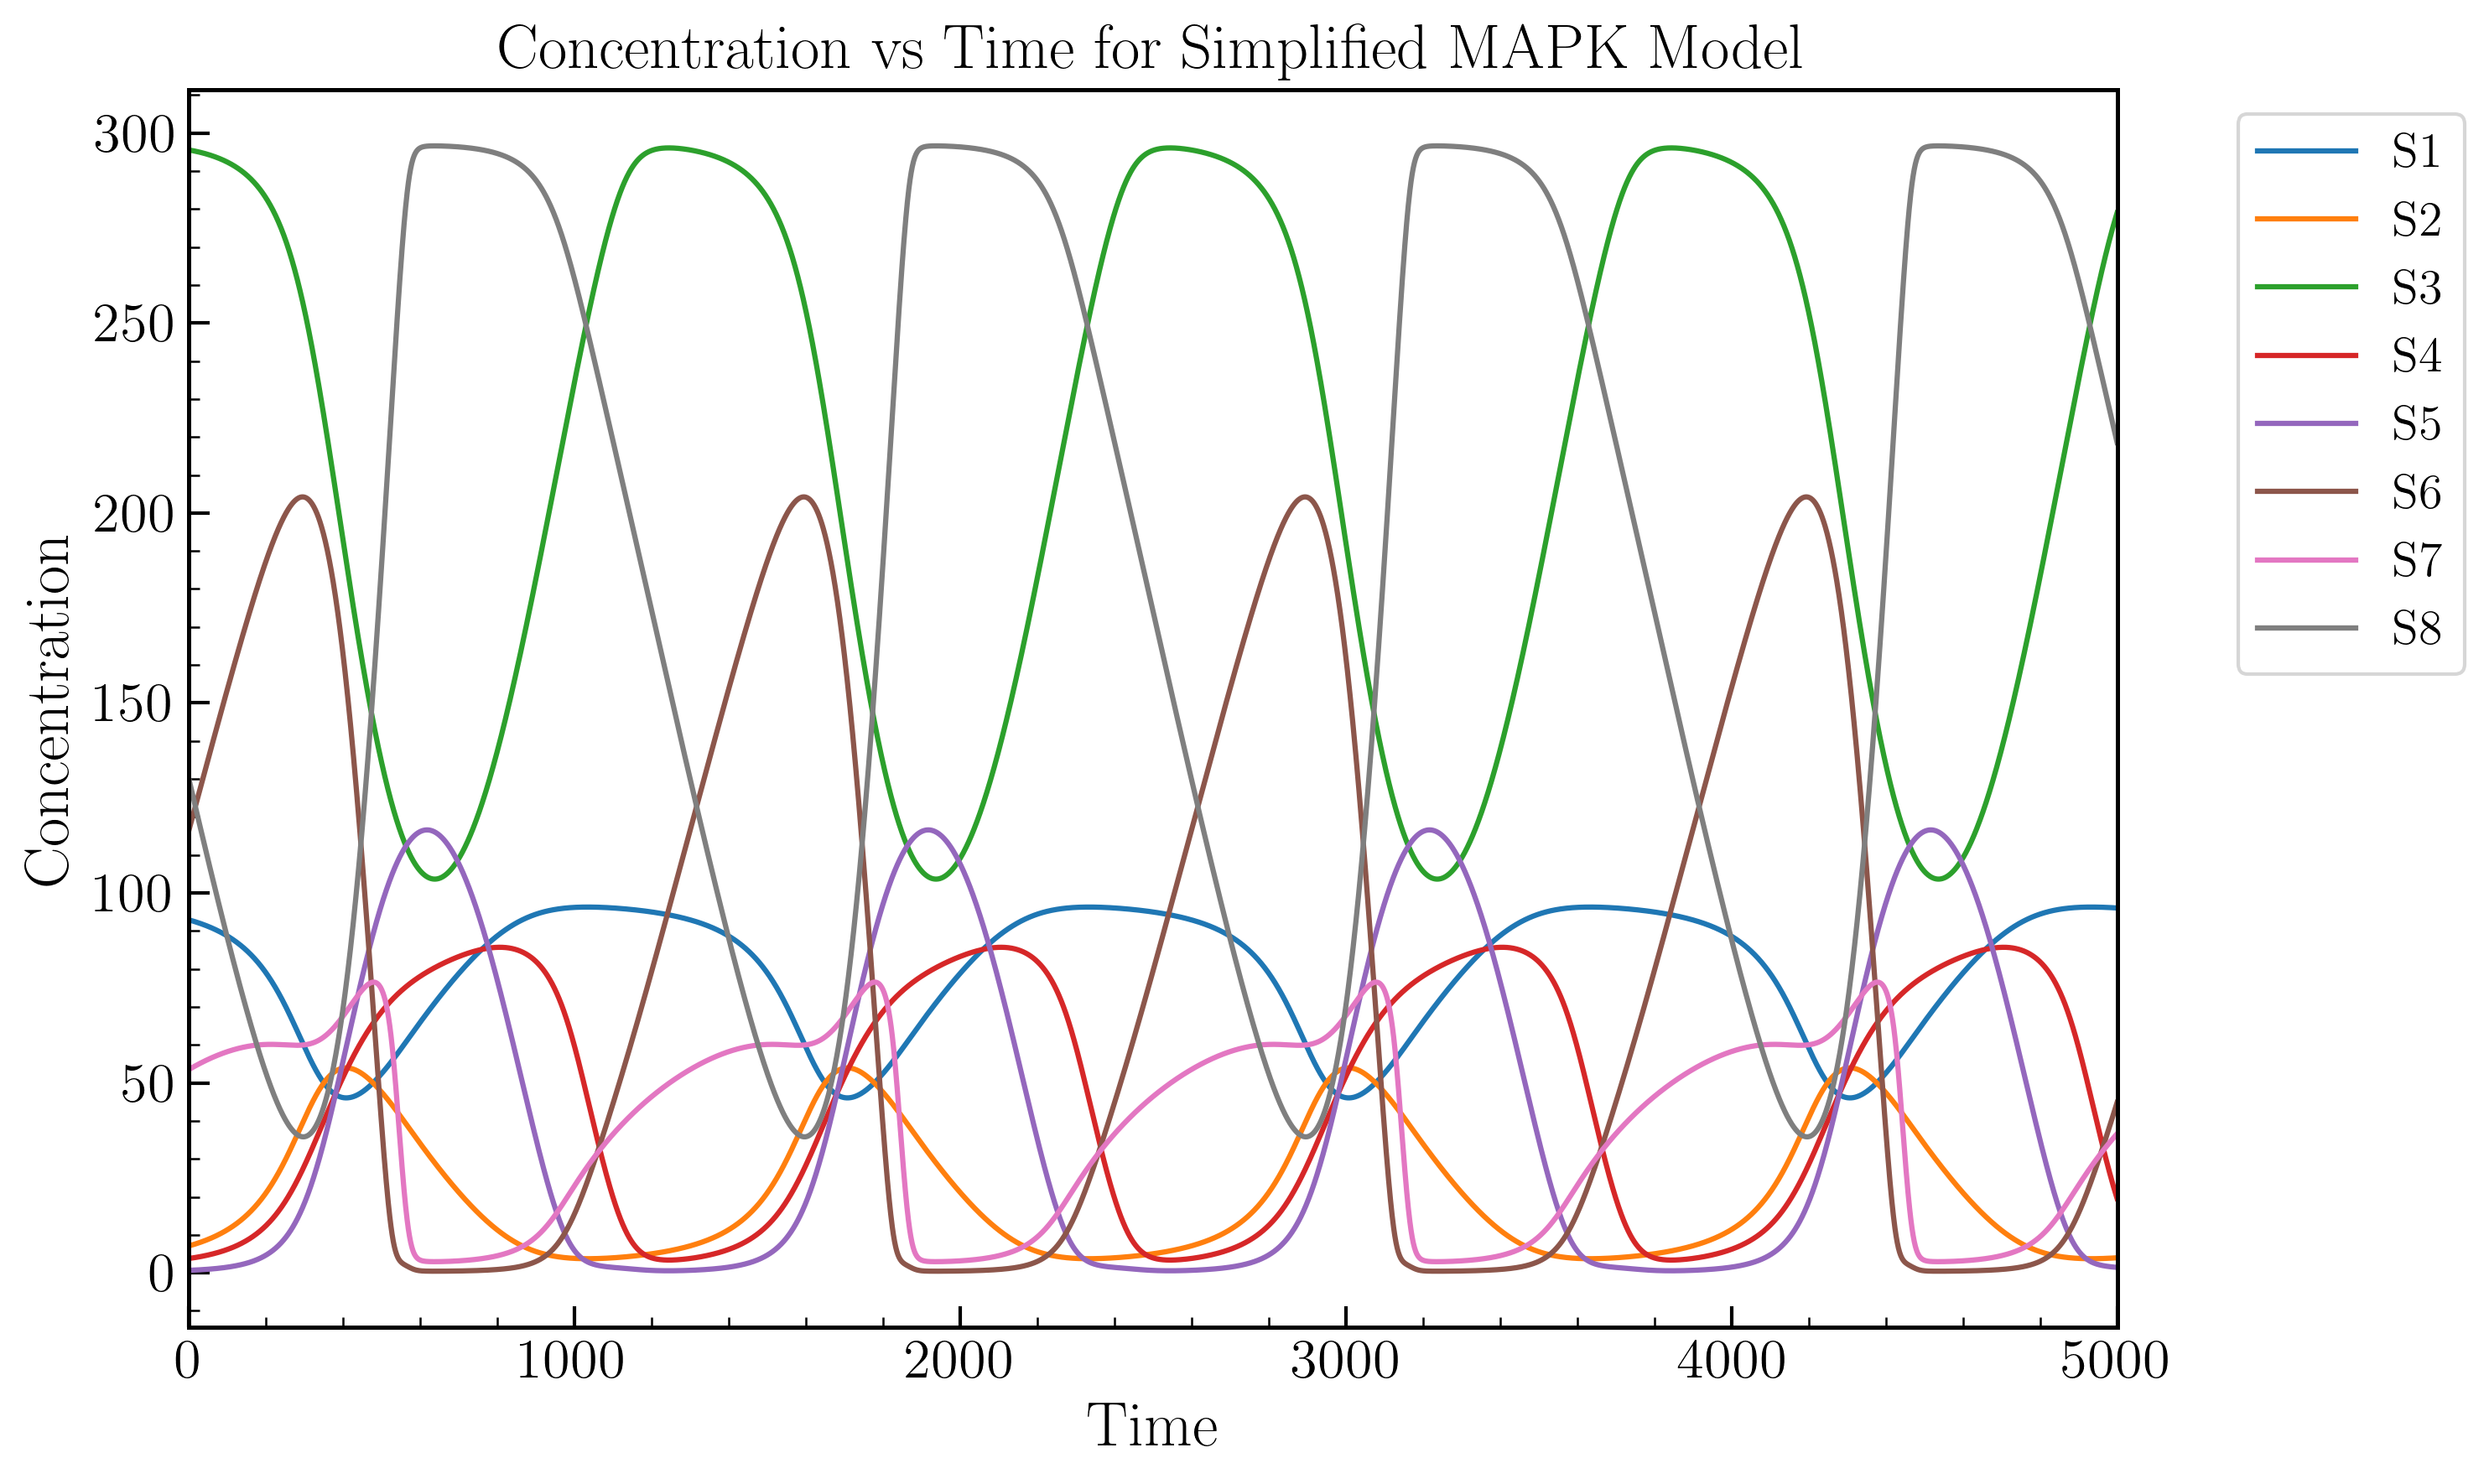

In [32]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y.T)
plt.xlim(0, 5000)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Concentration vs Time for Simplified MAPK Model')
plt.legend([f'S{i+1}' for i in range(8)], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [36]:
# Detect loops structure changes along the trajectory, count the same loop structures by a dictionary (eg: 0: 10, 2: 5, ...)
j_0 = numdifftools.Jacobian(lambda x: model_mapk_simple_w_feedback(x, klin, kn, n1),method="central")(sol.y[:, 0])
signed_jacobian_0 = np.sign(j_0)
initial_loop_list = ld.find_loops(j_0)
initial_loop_summary = ld.loop_summary(initial_loop_list)
J = numdifftools.Jacobian(
        lambda x: model_mapk_simple_w_feedback(x, klin, kn, n1),
        method="central"
    )

In [37]:
loop_structures = {"Loop 0": 0}
loop_structures_j = [signed_jacobian_0.tolist()]
loop_structures_count = 0
loop_structures_time_range = {"Loop 0": []}

temp_j_signed = signed_jacobian_0
temp_start_time = sol.t[0]

for t_idx in range(sol.y.shape[1]):
    j_matrix_t = J(sol.y[:, t_idx])

    signed_jacobian_t = np.sign(j_matrix_t)

    if signed_jacobian_t.tolist() != temp_j_signed.tolist():
        # close segment for OLD structure
        temp_end_time = sol.t[t_idx - 1] if t_idx > 0 else sol.t[0]

        old_idx = loop_structures_j.index(temp_j_signed.tolist())
        loop_structures[f"Loop {old_idx}"] += 1
        loop_structures_time_range[f"Loop {old_idx}"].append((temp_start_time, temp_end_time))
        print(f"Idx (closed old): {old_idx}, Time Range: {temp_start_time} - {temp_end_time}")

        # now switch to NEW structure (create if needed)
        if signed_jacobian_t.tolist() in loop_structures_j:
            new_idx = loop_structures_j.index(signed_jacobian_t.tolist())
        else:
            loop_structures_j.append(signed_jacobian_t.tolist())
            loop_structures_count += 1
            new_idx = loop_structures_count
            loop_structures[f"Loop {new_idx}"] = 0
            loop_structures_time_range[f"Loop {new_idx}"] = []

        temp_j_signed = signed_jacobian_t
        temp_start_time = sol.t[t_idx]

    # end of loop: close final segment for CURRENT (temp_j_signed)
    if t_idx == sol.y.shape[1] - 1:
        temp_end_time = sol.t[t_idx]
        cur_idx = loop_structures_j.index(temp_j_signed.tolist())
        loop_structures[f"Loop {cur_idx}"] += 1
        loop_structures_time_range[f"Loop {cur_idx}"].append((temp_start_time, temp_end_time))
        print(f"Idx (end): {cur_idx}, Time Range: {temp_start_time} - {temp_end_time}")


Idx (closed old): 0, Time Range: 0.0 - 108.0
Idx (closed old): 1, Time Range: 109.0 - 823.0
Idx (closed old): 0, Time Range: 824.0 - 1408.0
Idx (closed old): 1, Time Range: 1409.0 - 2122.0
Idx (closed old): 0, Time Range: 2123.0 - 2708.0
Idx (closed old): 1, Time Range: 2709.0 - 3422.0
Idx (closed old): 0, Time Range: 3423.0 - 4007.0
Idx (closed old): 1, Time Range: 4008.0 - 4722.0
Idx (end): 0, Time Range: 4723.0 - 5000.0


In [106]:
loop_structures

{'Loop 0': 5, 'Loop 1': 4}

In [103]:
loop_structures_time_range

{'Loop 0': [(np.float64(0.0), np.float64(108.0)),
  (np.float64(824.0), np.float64(1408.0)),
  (np.float64(2123.0), np.float64(2708.0)),
  (np.float64(3423.0), np.float64(4007.0)),
  (np.float64(4723.0), np.float64(5000.0))],
 'Loop 1': [(np.float64(109.0), np.float64(823.0)),
  (np.float64(1409.0), np.float64(2122.0)),
  (np.float64(2709.0), np.float64(3422.0)),
  (np.float64(4008.0), np.float64(4722.0))]}

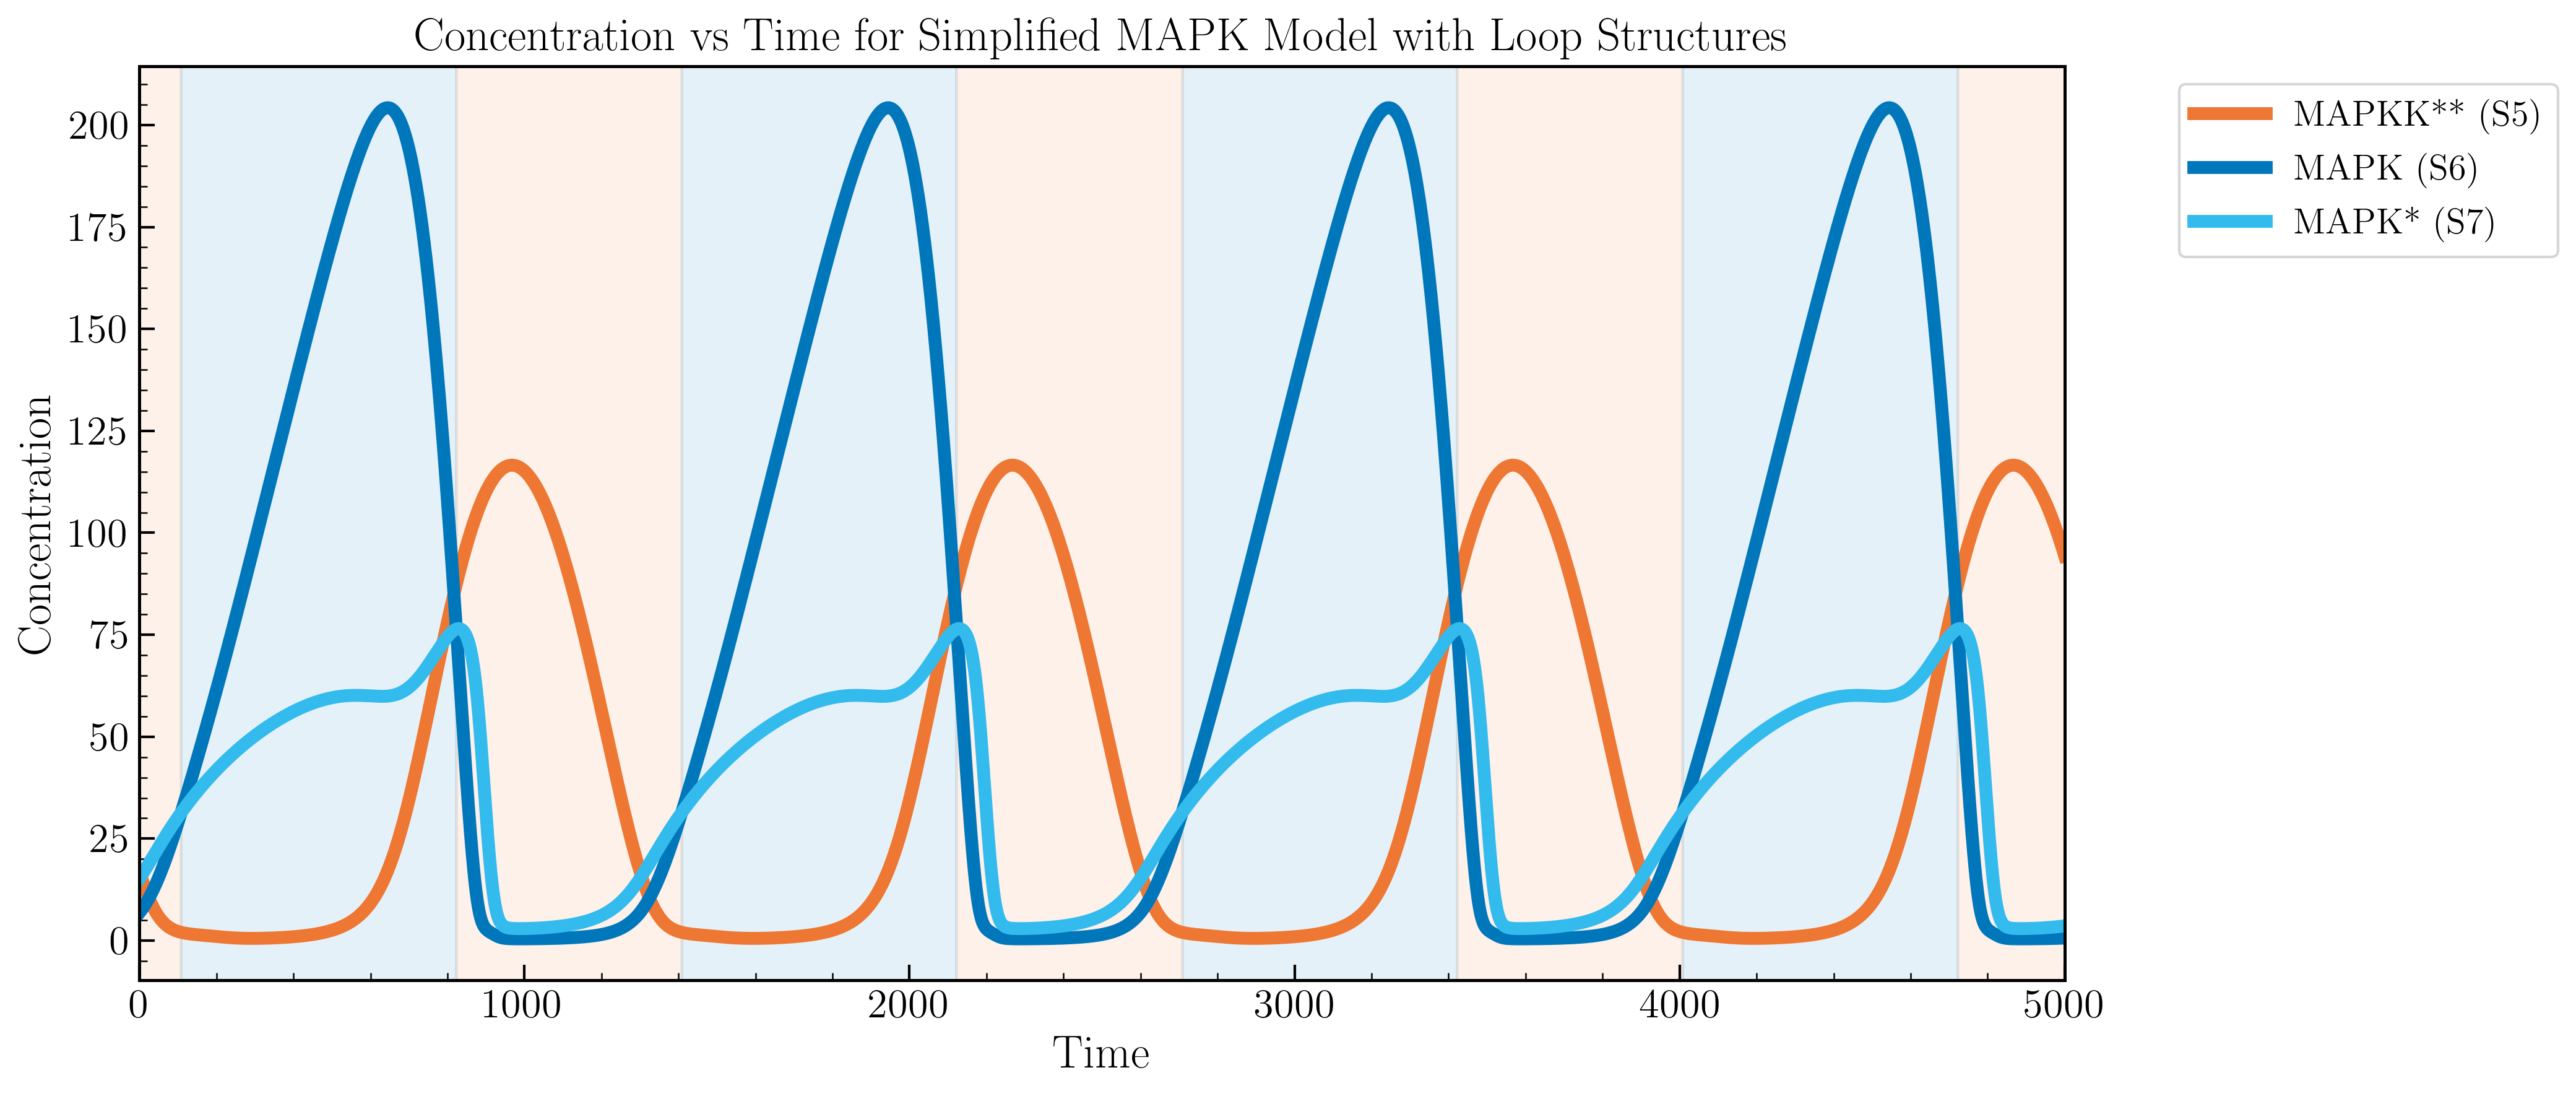

In [116]:
# Vizualize time ranges of different loop structures on the plot
plt.figure(figsize=(14, 6))
for i, c in enumerate(colors[:3]):
    plt.plot(sol.t, sol.y[investigate_index[i]], lw=5, color=c, label=investigate_label[i])
plt.xlim(0, 5000)
for loop_id, time_ranges in loop_structures_time_range.items():
    for (start, end) in time_ranges:
        plt.axvspan(start, end, alpha=0.1, color=colors[int(loop_id.split()[-1]) % len(colors)]) # label=loop_id, 
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Concentration vs Time for Simplified MAPK Model with Loop Structures')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


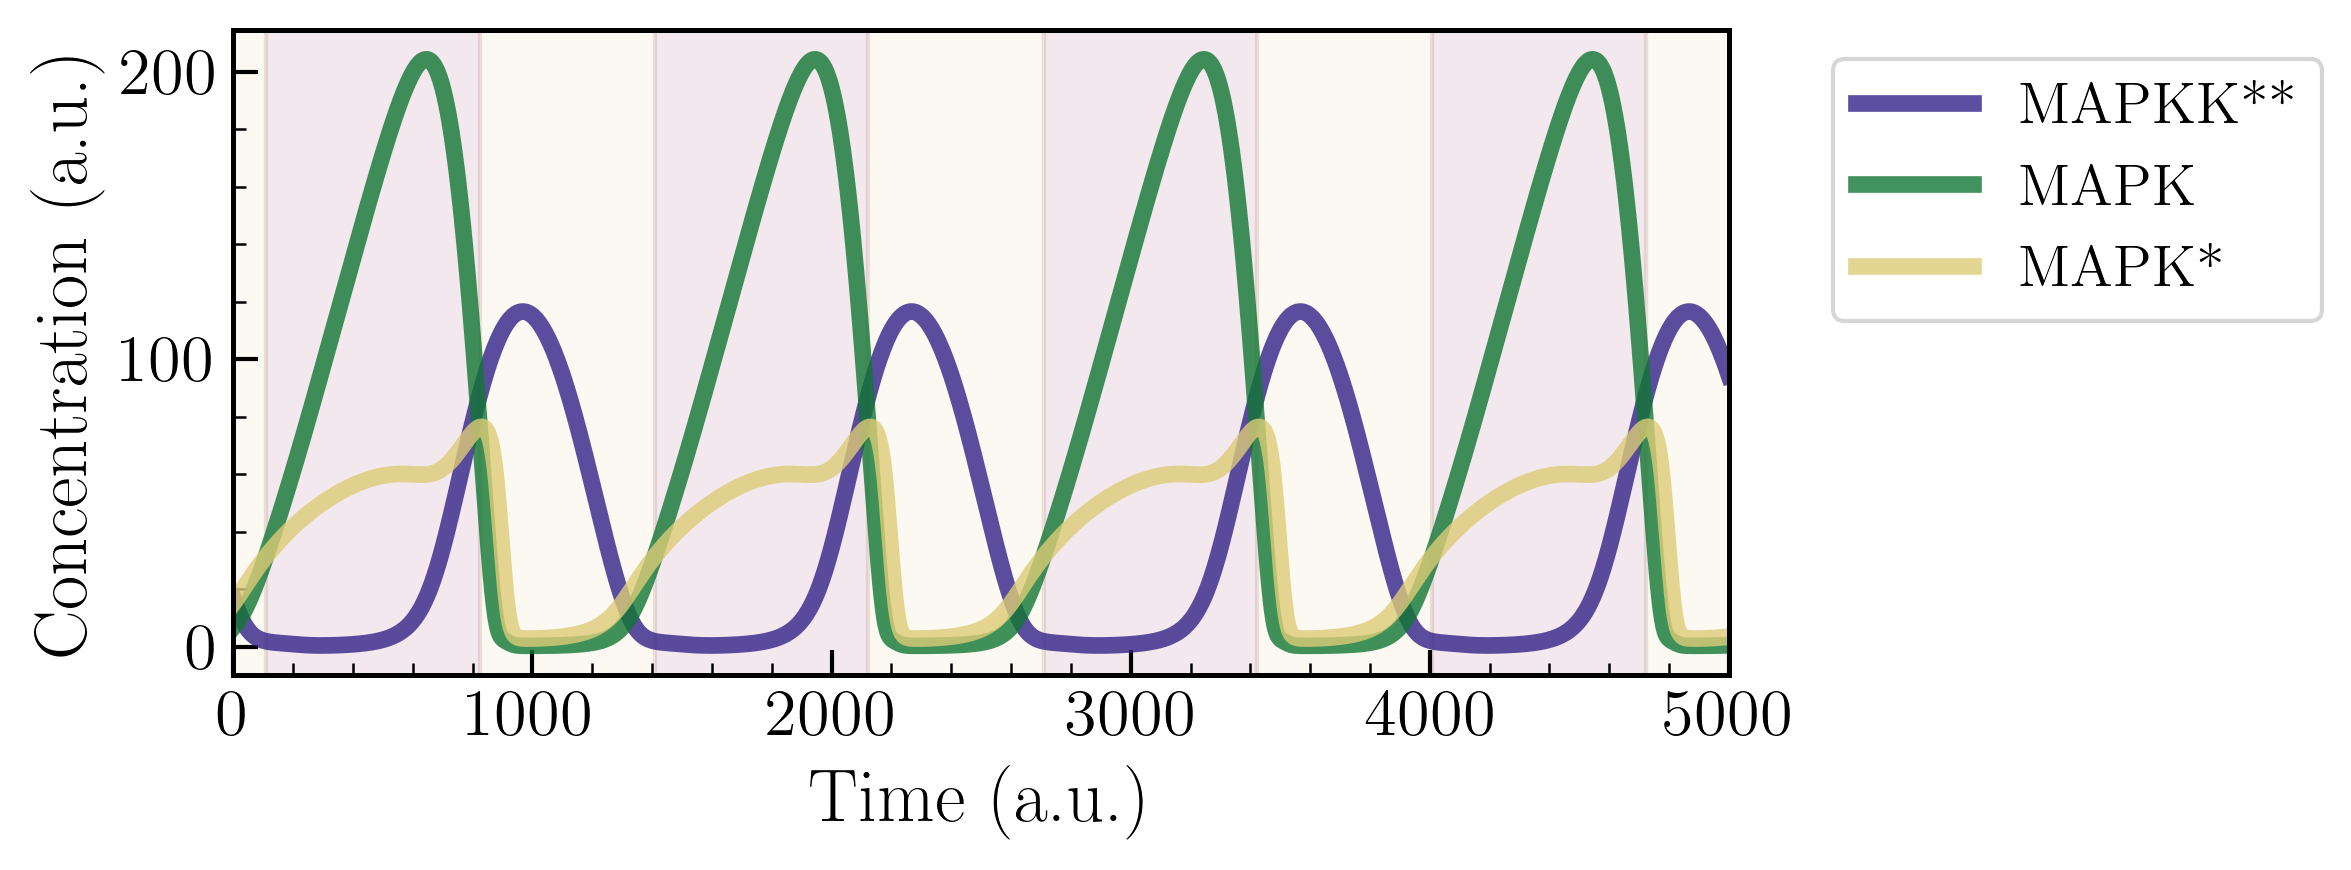

In [60]:
# Vizualize time ranges of different loop structures on the plot
# For paper

investigate_label = ['MAPKK**', 'MAPK', 'MAPK*']

plt.figure(figsize=(8, 3))
for i, c in enumerate(colors_02[:3]):
    plt.plot(sol.t, sol.y[investigate_index[i]], lw=4, color=c, label=investigate_label[i], alpha=0.8)
plt.xlim(0, 5000)
for loop_id, time_ranges in loop_structures_time_range.items():
    for (start, end) in time_ranges:
        plt.axvspan(start, end, alpha=0.1, color=colors_02[int(loop_id.split()[-1]) % len(colors_02)+2]) # label=loop_id, 
plt.xlabel('Time (a.u.)')
plt.ylabel('Concentration (a.u.)')
# plt.title('Concentration vs Time for Simplified MAPK Model with Loop Structures')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('img/figure_model5_mapk_dynamics_with_loop_structures.svg', dpi=300)
# plt.show()


In [62]:
# Jacobian calculation

j_matrix = numdifftools.Jacobian(lambda x: model_mapk_simple_w_feedback(x, klin, kn, n1),method="central")(sol.y[:, -1])
signed_jacobian = np.sign(j_matrix)

In [17]:
# Find loops
res_tab_complex = ld.find_loops_vset(model_mapk_simple_w_feedback,
                                     vset=[sol.y[:, -1]],
                                     klin=klin,
                                     kn=kn,
                                     n1=n1,
                                     max_num_loops=10,
                                     compute_full_list=True)
print(res_tab_complex['loop_rep'][0])

                          loop  length  sign
0                    (0, 1, 0)       2     1
1  (0, 1, 2, 3, 4, 5, 6, 7, 0)       8     1
2     (0, 1, 2, 3, 4, 6, 7, 0)       7     1
3        (0, 1, 2, 3, 4, 7, 0)       6    -1
4     (0, 1, 3, 4, 5, 6, 7, 0)       7    -1
5        (0, 1, 3, 4, 6, 7, 0)       6    -1
6           (0, 1, 3, 4, 7, 0)       5     1
7        (0, 1, 4, 5, 6, 7, 0)       6    -1
8           (0, 1, 4, 6, 7, 0)       5    -1
9              (0, 1, 4, 7, 0)       4     1


In [18]:
loop_list = ld.find_loops(j_matrix)
ld.loop_summary(loop_list)

length,1,2
total,6,1
neg,6,0
pos,0,1


In [19]:
# Loop 0 structure:
j_matrix_loop0 = numdifftools.Jacobian(lambda x: model_mapk_simple_w_feedback(x, klin, kn, n1),method="central")(sol.y[:, 0])
signed_jacobian_loop0 = np.sign(j_matrix_loop0)
print("Signed Jacobian matrix (Loop 0):")
print(signed_jacobian_loop0)

Signed Jacobian matrix (Loop 0):
[[-1.  1.  0.  0.  0.  0.  0.  1.]
 [ 1. -1.  0.  0.  0.  0.  0. -1.]
 [ 0. -1. -1.  1.  0.  0.  0.  0.]
 [ 0.  1.  1. -1.  1.  0.  0.  0.]
 [ 0.  1.  0.  1. -1.  0.  0.  0.]
 [ 0.  0.  0.  0. -1. -1.  1.  0.]
 [ 0.  0.  0.  0. -1.  1. -1.  1.]
 [ 0.  0.  0.  0.  1.  0.  1. -1.]]


In [20]:
# Loop 1 structure:
j_matrix_loop1 = numdifftools.Jacobian(lambda x: model_mapk_simple_w_feedback(x, klin, kn, n1),method="central")(sol.y[:, 4500])
signed_jacobian_loop1 = np.sign(j_matrix_loop1)
print("Signed Jacobian matrix (Loop 1):")
print(signed_jacobian_loop1)

Signed Jacobian matrix (Loop 1):
[[-1.  1.  0.  0.  0.  0.  0.  1.]
 [ 1. -1.  0.  0.  0.  0.  0. -1.]
 [ 0. -1. -1.  1.  0.  0.  0.  0.]
 [ 0.  1.  1. -1.  1.  0.  0.  0.]
 [ 0.  1.  0.  1. -1.  0.  0.  0.]
 [ 0.  0.  0.  0. -1. -1.  1.  0.]
 [ 0.  0.  0.  0.  1.  1. -1.  1.]
 [ 0.  0.  0.  0.  1.  0.  1. -1.]]


In [21]:
# Loop summary for Loop 0
loop_list_0 = ld.find_loops(j_matrix_loop0)
ld.loop_summary(loop_list_0)

length,1,2,3,4,5,6,7,8
total,8,5,1,3,5,5,3,1
neg,8,0,1,1,1,4,2,0
pos,0,5,0,2,4,1,1,1


In [22]:
# Loop summary for Loop 1
loop_list_1 = ld.find_loops(j_matrix_loop1)
ld.loop_summary(loop_list_1)

length,1,2,3,4,5,6,7,8
total,8,5,1,3,5,5,3,1
neg,8,0,1,2,1,2,3,0
pos,0,5,0,1,4,3,0,1


In [24]:
id_to_subject = {
    0: 'MAPKKK (S1)',
    1: 'MAPKKK* (S2)',
    2: 'MAPKK (S3)',
    3: 'MAPKK* (S4)',
    4: 'MAPKK** (S5)',
    5: 'MAPK (S6)',
    6: 'MAPK* (S7)',
    7: 'MAPK** (S8)'
}

df = pd.DataFrame(res_tab_complex['loop_rep'][0]).sort_values(by=['length','loop'])

df["loop_subject"] = df["loop"].apply(
    lambda t: tuple(id_to_subject[i] for i in t)
)
pd.set_option('display.max_colwidth', None)
df

,loop,length,sign,loop_subject
0,"(0, 1, 0)",2,1,"(MAPKKK (S1), MAPKKK* (S2), MAPKKK (S1))"
9,"(0, 1, 4, 7, 0)",4,1,"(MAPKKK (S1), MAPKKK* (S2), MAPKK** (S5), MAPK** (S8), MAPKKK (S1))"
6,"(0, 1, 3, 4, 7, 0)",5,1,"(MAPKKK (S1), MAPKKK* (S2), MAPKK* (S4), MAPKK** (S5), MAPK** (S8), MAPKKK (S1))"
8,"(0, 1, 4, 6, 7, 0)",5,-1,"(MAPKKK (S1), MAPKKK* (S2), MAPKK** (S5), MAPK* (S7), MAPK** (S8), MAPKKK (S1))"
3,"(0, 1, 2, 3, 4, 7, 0)",6,-1,"(MAPKKK (S1), MAPKKK* (S2), MAPKK (S3), MAPKK* (S4), MAPKK** (S5), MAPK** (S8), MAPKKK (S1))"
5,"(0, 1, 3, 4, 6, 7, 0)",6,-1,"(MAPKKK (S1), MAPKKK* (S2), MAPKK* (S4), MAPKK** (S5), MAPK* (S7), MAPK** (S8), MAPKKK (S1))"
7,"(0, 1, 4, 5, 6, 7, 0)",6,-1,"(MAPKKK (S1), MAPKKK* (S2), MAPKK** (S5), MAPK (S6), MAPK* (S7), MAPK** (S8), MAPKKK (S1))"
2,"(0, 1, 2, 3, 4, 6, 7, 0)",7,1,"(MAPKKK (S1), MAPKKK* (S2), MAPKK (S3), MAPKK* (S4), MAPKK** (S5), MAPK* (S7), MAPK** (S8), MAPKKK (S1))"
4,"(0, 1, 3, 4, 5, 6, 7, 0)",7,-1,"(MAPKKK (S1), MAPKKK* (S2), MAPKK* (S4), MAPKK** (S5), MAPK (S6), MAPK* (S7), MAPK** (S8), MAPKKK (S1))"
1,"(0, 1, 2, 3, 4, 5, 6, 7, 0)",8,1,"(MAPKKK (S1), MAPKKK* (S2), MAPKK (S3), MAPKK* (S4), MAPKK** (S5), MAPK (S6), MAPK* (S7), MAPK** (S8), MAPKKK (S1))"


In [33]:
# Loop 0

signed_jacobian = signed_jacobian_loop0
labels = [id_to_subject[i] for i in range(signed_jacobian.shape[0])]
regulation_info_0 = pd.DataFrame(signed_jacobian, columns=[labels[i] for i in range(signed_jacobian.shape[1])], index=[labels[i] for i in range(signed_jacobian.shape[0])])
regulation_info_0 = regulation_info_0.stack().reset_index()
regulation_info_0.columns = ['to', 'from', 'regulation']

# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info_0['regulation_words'] = regulation_info_0['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
# Show all regulations in Loop 0
pd.set_option('display.max_rows', None)
regulation_info_0

,to,from,regulation,regulation_words
0,MAPKKK (S1),MAPKKK (S1),-1.0,inhibition (negative)
1,MAPKKK (S1),MAPKKK* (S2),1.0,activation (positive)
2,MAPKKK (S1),MAPKK (S3),0.0,no regulation
3,MAPKKK (S1),MAPKK* (S4),0.0,no regulation
4,MAPKKK (S1),MAPKK** (S5),0.0,no regulation
5,MAPKKK (S1),MAPK (S6),0.0,no regulation
6,MAPKKK (S1),MAPK* (S7),0.0,no regulation
7,MAPKKK (S1),MAPK** (S8),1.0,activation (positive)
8,MAPKKK* (S2),MAPKKK (S1),1.0,activation (positive)
9,MAPKKK* (S2),MAPKKK* (S2),-1.0,inhibition (negative)


In [26]:
# Loop 1
signed_jacobian = signed_jacobian_loop1
labels = [id_to_subject[i] for i in range(signed_jacobian.shape[0])]
regulation_info_1 = pd.DataFrame(signed_jacobian, columns=[labels[i] for i in range(signed_jacobian.shape[1])], index=[labels[i] for i in range(signed_jacobian.shape[0])])
regulation_info_1 = regulation_info_1.stack().reset_index()
regulation_info_1.columns = ['to', 'from', 'regulation']

# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info_1['regulation_words'] = regulation_info_1['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
regulation_info_1

,to,from,regulation,regulation_words
0,MAPKKK (S1),MAPKKK (S1),-1.0,inhibition (negative)
1,MAPKKK (S1),MAPKKK* (S2),1.0,activation (positive)
2,MAPKKK (S1),MAPKK (S3),0.0,no regulation
3,MAPKKK (S1),MAPKK* (S4),0.0,no regulation
4,MAPKKK (S1),MAPKK** (S5),0.0,no regulation
...,...,...,...,...
59,MAPK** (S8),MAPKK* (S4),0.0,no regulation
60,MAPK** (S8),MAPKK** (S5),1.0,activation (positive)
61,MAPK** (S8),MAPK (S6),0.0,no regulation
62,MAPK** (S8),MAPK* (S7),1.0,activation (positive)


In [28]:
diff = regulation_info_0.merge(regulation_info_1, on=['to', 'from'], suffixes=('_loop0', '_loop1'))
diff['regulation_change'] = diff['regulation_loop0'] != diff['regulation_loop1']
diff[diff['regulation_change']==True]

,to,from,regulation_loop0,regulation_words_loop0,regulation_loop1,regulation_words_loop1,regulation_change
52,MAPK* (S7),MAPKK** (S5),-1.0,inhibition (negative),1.0,activation (positive),True


## 2.2. Reduced MAPK **without** explicit feedback regulation

In [16]:
def model_mapk_simple_wo_feedback(y, klin, kn, n1):
    S1, S2, S3, S4, S5, S6, S7, S8 = y
    
    # Unpack kinetic parameters
    k1, k2, k3, k4, k5, k6, k7, k8, k9, k10 = klin
    
    # Unpack saturation constants
    kn1, kn2, kn3, kn4, kn5, kn6, kn7, kn8, kn9, kn10, kn11 = kn
    
    # dS1/dt
    # term_inhibit = (kn1**n1) / (kn1**n1 + S8**n1)
    dS1 = -k1 * (S1/(kn2 + S1)) \
          + k2 * (S2/(S2 + kn3))
    
    # dS2/dt
    dS2 =  k1 * (S1/(kn2 + S1)) \
          - k2 * (S2/(S2 + kn3))
    
    # dS3/dt
    dS3 = k6 * (S4/(kn7 + S4)) \
          - k3 * (S2*S3/(kn4 + S3))
    
    # dS4/dt
    dS4 = k3 * (S2*S3/(kn4 + S3)) \
          - k6 * (S4/(kn7 + S4)) \
          + k5 * (S5/(kn6 + S5)) \
          - k4 * (S2*S4/(kn5 + S4))
    
    # dS5/dt
    dS5 = k4 * (S2*S4/(kn5 + S4)) \
          - k5 * (S5/(kn6 + S5))
    
    # dS6/dt
    dS6 = k10 * (S7/(kn11 + S7)) \
          - k7 * (S5*S6/(kn8 + S6))
    
    # dS7/dt
    dS7 =  k7 * (S5*S6/(kn8 + S6)) \
            - k10 * (S7/(kn11 + S7)) \
            - k8 * (S5*S7/(kn9 + S7)) \
            + k9 * (S8/(kn10 + S8))
    
    # dS8/dt
    dS8 =  k8 * (S5*S7/(kn9 + S7)) \
           - k9 * (S8/(kn10 + S8))
    
    return np.array([dS1, dS2, dS3, dS4, dS5, dS6, dS7, dS8], dtype=float)

def solve_model_mapk_simple_wo_feedback(initial_conditions, time_points, klin, kn, n1):
    def ode(t, x):
        return model_mapk_simple_wo_feedback(x, klin, kn, n1)
    
    sol = solve_ivp(
        ode,
        [time_points[0], time_points[-1]],
        initial_conditions,
        t_eval=time_points,
        method="RK45",
        rtol=1e-6,
        atol=1e-9
    )
    return sol


In [17]:
investigate_label = ['MAPKK** (S5)', 'MAPK** (S8)']
investigate_index = [4, 7]

In [18]:
sol = solve_model_mapk_simple_wo_feedback(initial_conditions,
                              time_points=np.linspace(0, 500, 501),
                                klin=klin,
                                kn=kn,
                                n1=n1)

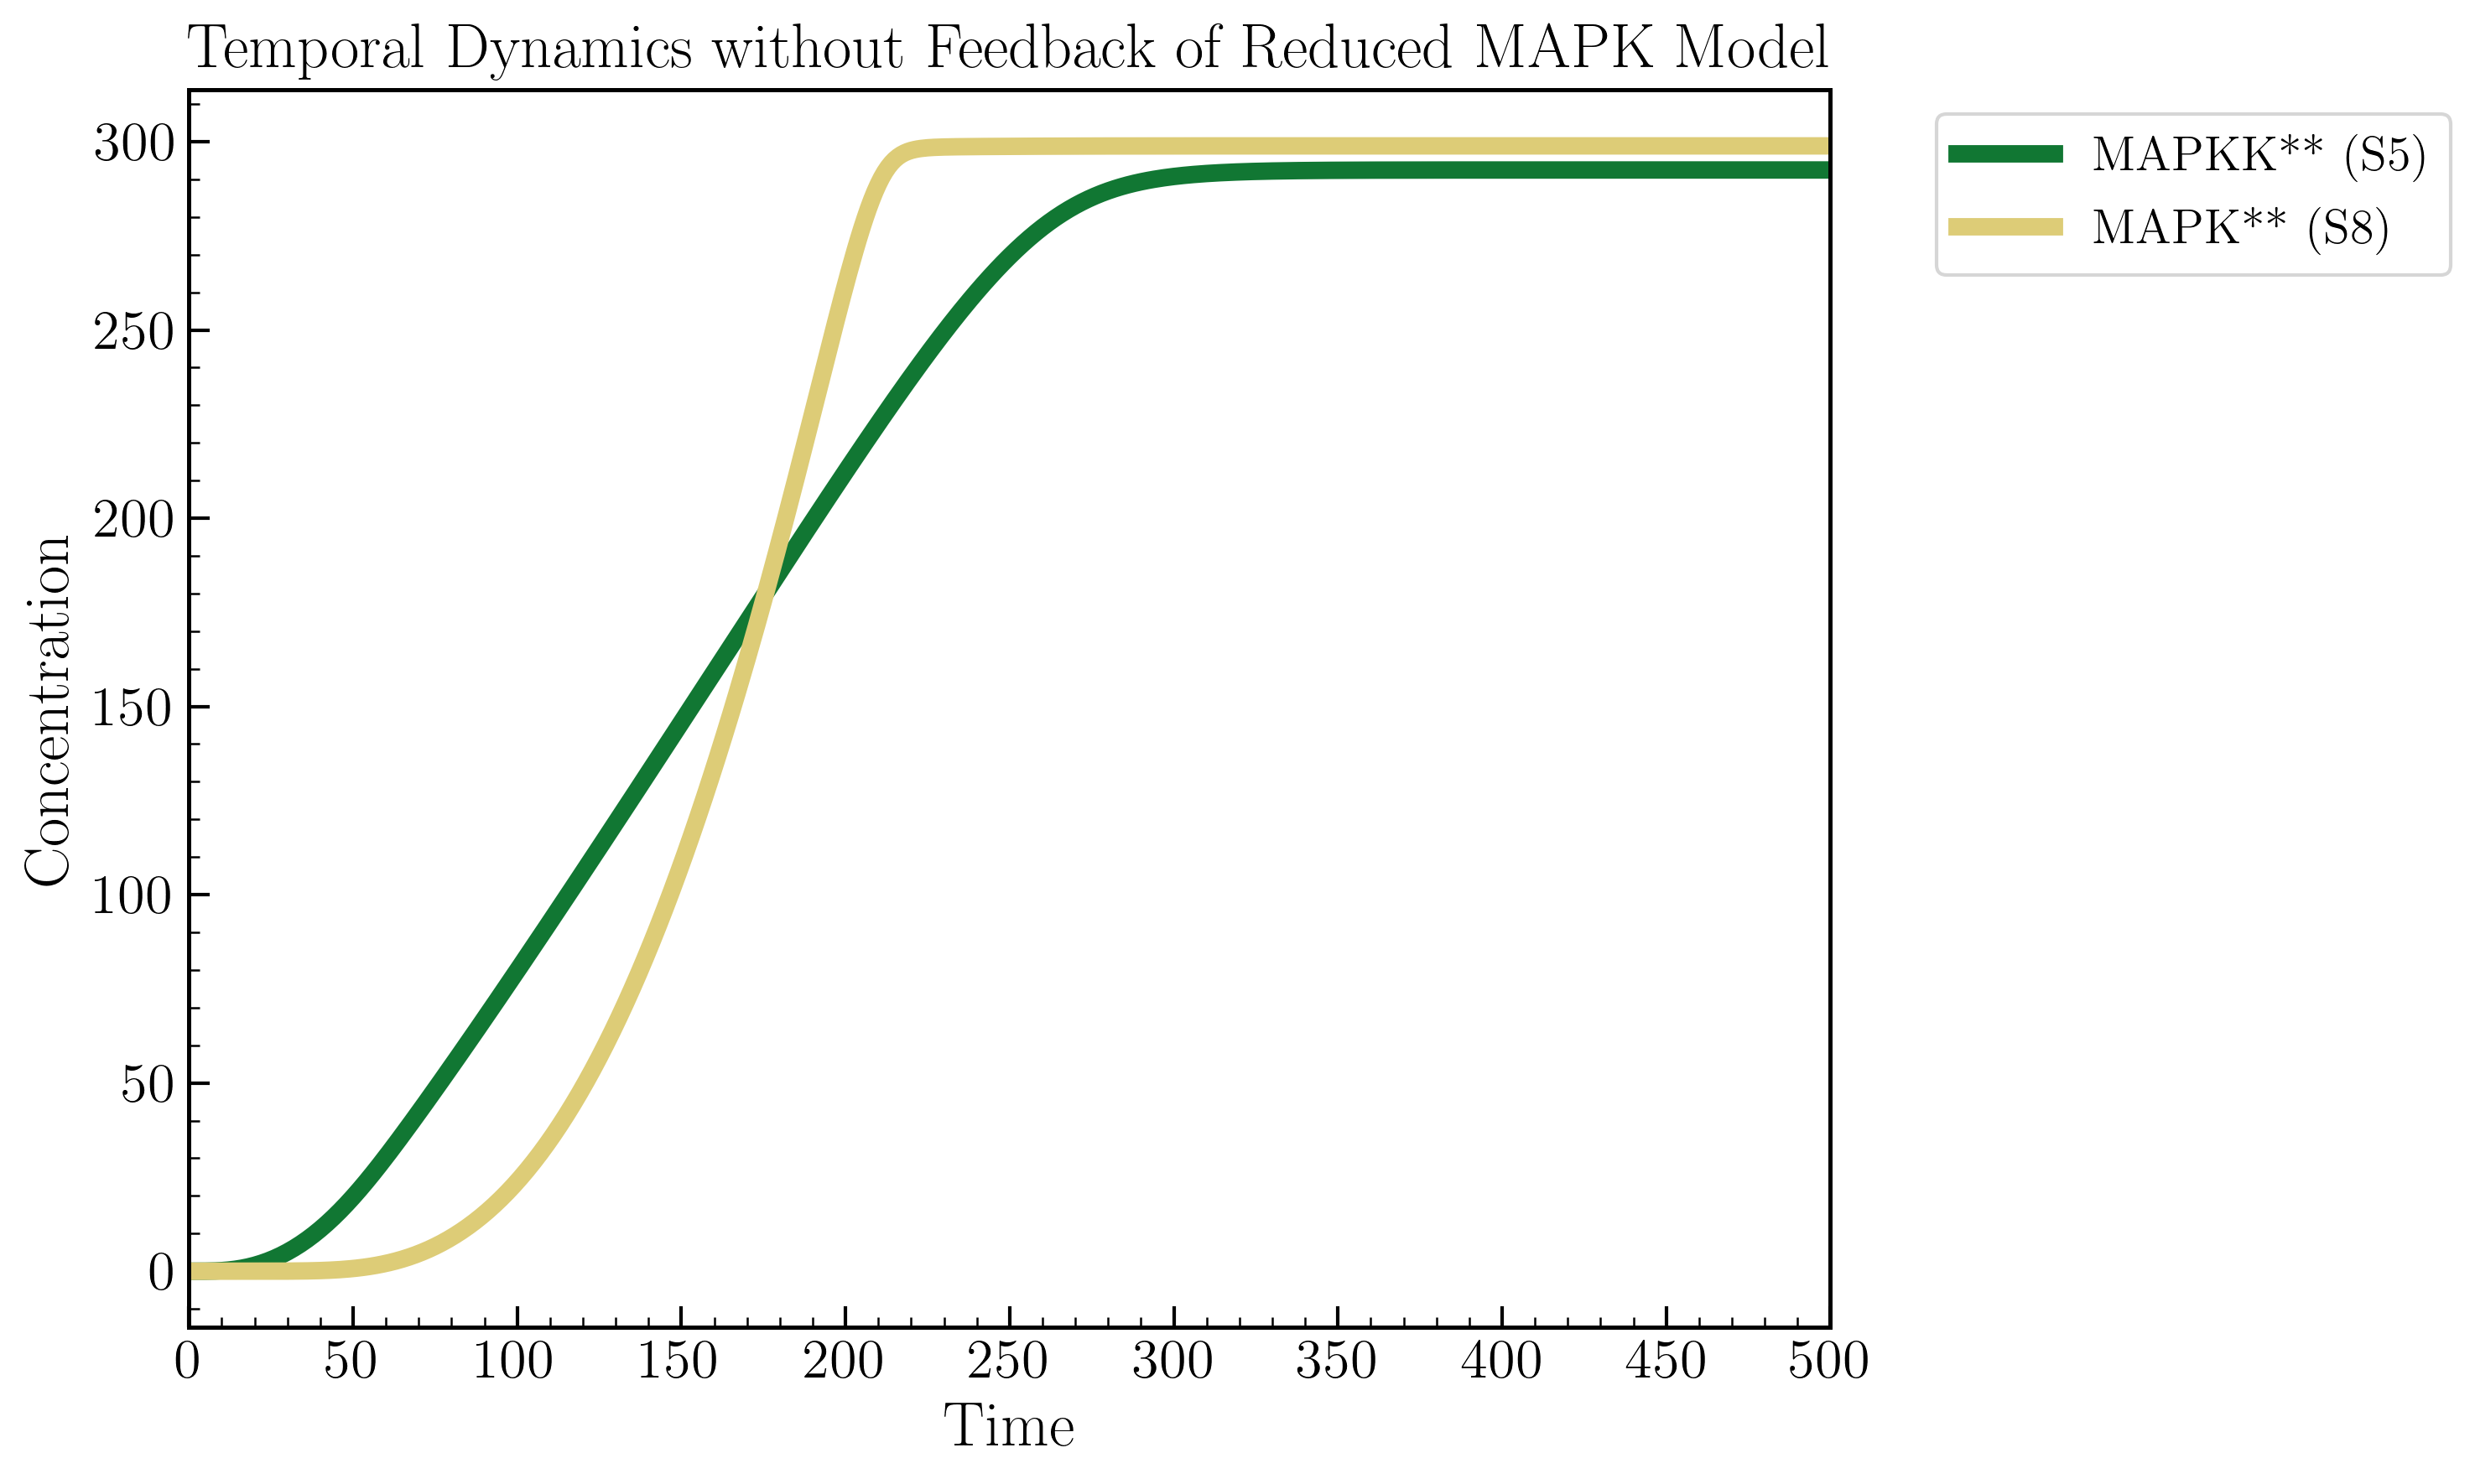

In [19]:
# Plot
plt.figure(figsize=(10, 6))
for i, c in enumerate(colors_02[1:3]):
    plt.plot(sol.t, sol.y[investigate_index[i]], lw=5, color=c, label=investigate_label[i])
plt.xlim(0, 500)
plt.xticks(np.arange(0, 501, 50))
# plt.ylim(0, 300)
# plt.yticks(np.arange(0, 301, 50))
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Temporal Dynamics without Feedback of Reduced MAPK Model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

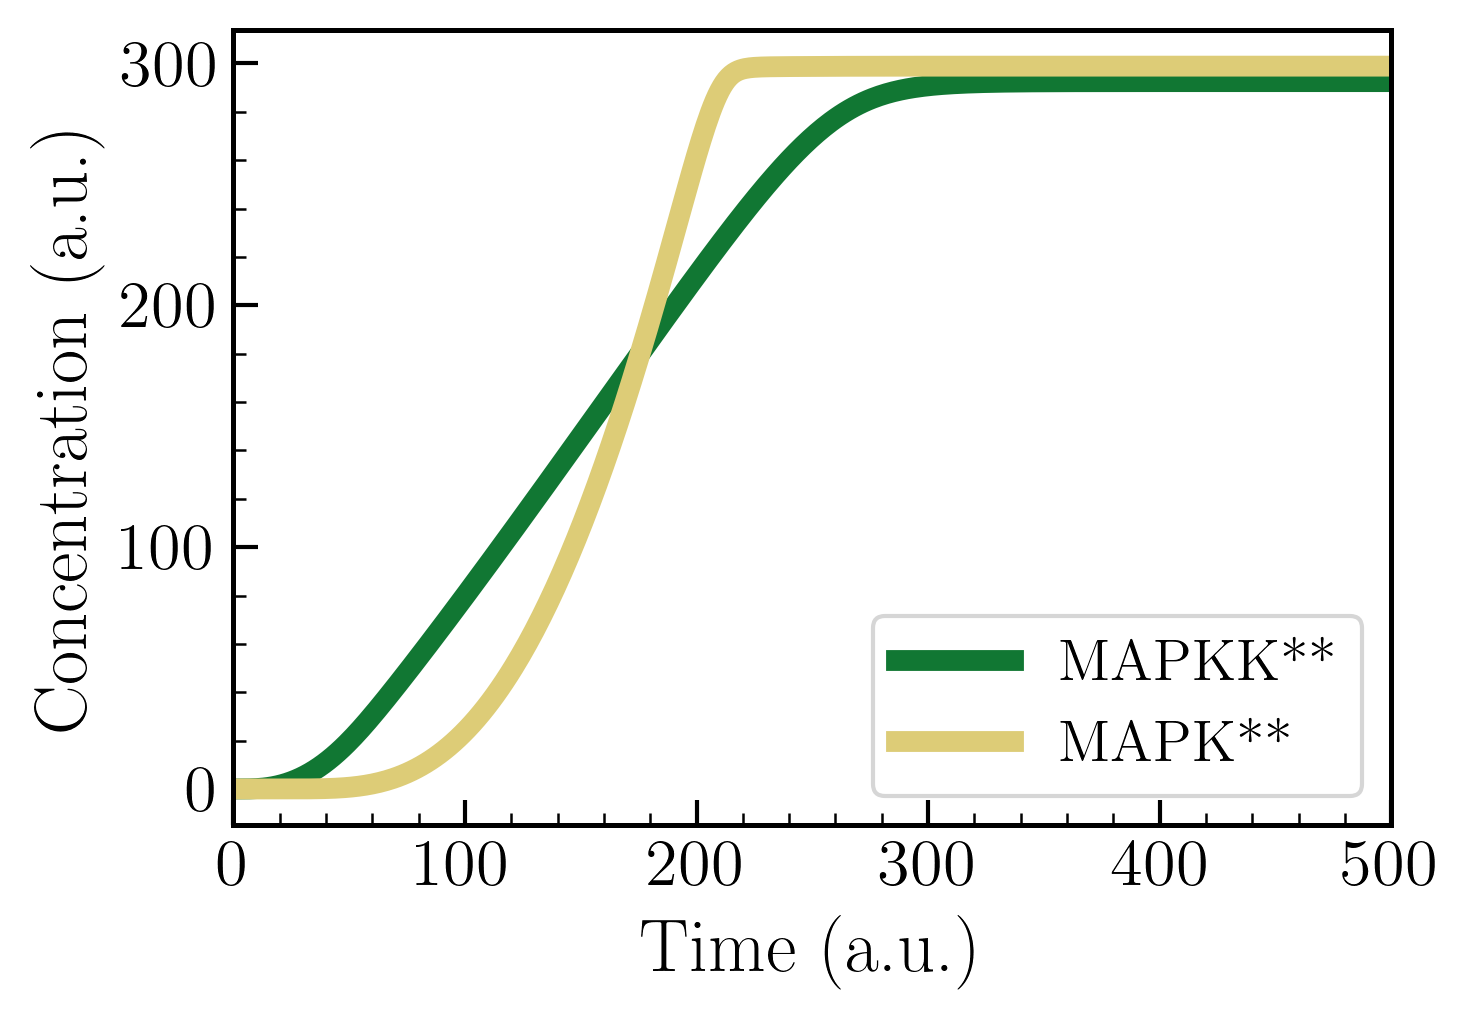

In [26]:
# Plot for paper
investigate_label = ['MAPKK**', 'MAPK**']
plt.figure(figsize=(5, 3.5))
for i, c in enumerate(colors_02[1:3]):
    plt.plot(sol.t, sol.y[investigate_index[i]], lw=5, color=c, label=investigate_label[i])
plt.xlim(0, 500)
plt.xticks(np.arange(0, 501, 100))
# plt.ylim(0, 300)
# plt.yticks(np.arange(0, 301, 50))
plt.xlabel('Time (a.u.)')
plt.ylabel('Concentration (a.u.)')
# plt.title('Temporal Dynamics without Feedback of Reduced MAPK Model')
plt.legend(loc='lower right') #bbox_to_anchor=(1.05, 1), 
plt.tight_layout()
plt.savefig('img/figure_model5_mapk_dynamics_without_feedback.svg', dpi=300)
plt.show()

In [126]:
j_matrix = numdifftools.Jacobian(lambda x: model_mapk_simple_wo_feedback(x, klin, kn, n1),method="central")(sol.y[:, -1])
signed_jacobian = np.sign(j_matrix)
print(signed_jacobian)

[[-1.  1.  0.  0.  0.  0.  0.  0.]
 [ 1. -1.  0.  0.  0.  0.  0.  0.]
 [ 0. -1. -1.  1.  0.  0.  0.  0.]
 [ 0. -1.  1. -1.  1.  0.  0.  0.]
 [ 0.  1.  0.  1. -1.  0.  0.  0.]
 [ 0.  0.  0.  0. -1. -1.  1.  0.]
 [ 0.  0.  0.  0. -1.  1. -1.  1.]
 [ 0.  0.  0.  0.  1.  0.  1. -1.]]


In [127]:
res_tab = ld.find_loops_vset(model_mapk_simple_wo_feedback,
                                     vset=[sol.y[:, -1]],
                                        klin=klin,
                                        kn=kn,
                                        n1=n1)
print(res_tab['loop_rep'][0])

         loop  length  sign
0   (5, 6, 5)       2     1
1   (6, 7, 6)       2     1
2   (2, 3, 2)       2     1
3   (3, 4, 3)       2     1
4   (0, 1, 0)       2     1
5      (0, 0)       1    -1
6      (1, 1)       1    -1
7      (2, 2)       1    -1
8      (3, 3)       1    -1
9      (4, 4)       1    -1
10     (5, 5)       1    -1
11     (6, 6)       1    -1
12     (7, 7)       1    -1


In [128]:
loop_list = ld.find_loops(j_matrix)
ld.loop_summary(loop_list)

length,1,2
total,8,5
neg,8,0
pos,0,5
